<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/ML_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ML Assignment 1 (Advanced): Predictive Supply Chain Analytics**


atomcamp | Machine Learning Boot Camp

In [1]:
# Install only the required libraries
!pip -q install pandas numpy matplotlib seaborn scikit-learn

In [2]:
# Data handling
import numpy as np
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)

In [3]:
# Upload the supplied CSV file

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("oil_gas_supply_chain.csv")

print("Dataset shape:", df.shape)
display(df.head())

Saving oil_gas_supply_chain.csv to oil_gas_supply_chain.csv
Dataset shape: (1800, 10)


,Transaction_ID,Origin_Region,Transport_Mode,Distance_km,Volume_Barrels,Ambient_Temp_C,Pipeline_Pressure_PSI,Transit_Delay_Risk_Index,Operator_Experience_Yrs,Shipment_Delayed
0,TXN_2000,Permian Basin,Tanker Truck,73.280948,20913.88487,47.5,NaN,1.60,19,0
1,TXN_2001,Permian Basin,Maritime Tanker,6816.818590,589840.35560,-5.4,NaN,0.65,4,0
2,TXN_2002,Middle East,Pipeline,691.079450,137623.09880,4.0,800.443547,5.06,7,0
3,TXN_2003,Middle East,Tanker Truck,74.584274,13756.31376,-13.9,NaN,4.28,13,1
4,TXN_2004,Permian Basin,Maritime Tanker,7670.921813,496916.56300,42.1,NaN,1.31,5,1


Phase 1: Advanced EDA & Preprocessing — 30 Marks

Question 1: Structural Missingness & Domain Imputation — 10 Marks
1.1 Detect missing values


In [4]:
# Count and calculate the percentage of missing values

missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": df.isna().mean() * 100
})

display(
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
)

,Missing_Count,Missing_Percentage
Ambient_Temp_C,104,5.777778
Pipeline_Pressure_PSI,1111,61.722222


1.2 Analyze pipeline-pressure missingness

In [5]:
# Check pressure missingness for every transport mode

pressure_missing_by_mode = pd.crosstab(
    df["Transport_Mode"],
    df["Pipeline_Pressure_PSI"].isna()
)

pressure_missing_by_mode.columns = [
    "Pressure_Available",
    "Pressure_Missing"
]

display(pressure_missing_by_mode)

,Pressure_Available,Pressure_Missing
Transport_Mode,,
Maritime Tanker,0,561
Pipeline,689,0
Railcar,0,270
Tanker Truck,0,280


1.3 Split before learning imputation values

In [6]:
# Separate input features and target

X_raw = df.drop(columns="Shipment_Delayed")
y = df["Shipment_Delayed"]

# 70% training and 30% temporary data
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

# Divide temporary data into 15% validation and 15% test
# Second: divide the temporary 30% equally
# 50% of 30% = 15%
X_validation_raw, X_test_raw, y_validation, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Training:", X_train_raw.shape)
print("Validation:", X_validation_raw.shape)
print("Test:", X_test_raw.shape)

Training: (1260, 9)
Validation: (270, 9)
Test: (270, 9)


1.4 Learn domain-imputation values from training data

In [7]:
# Use only valid pipeline pressure when calculating the median

valid_training_pressure = X_train_raw.loc[
    (X_train_raw["Transport_Mode"] == "Pipeline")
    & (X_train_raw["Pipeline_Pressure_PSI"] >= 0),
    "Pipeline_Pressure_PSI"
]

pipeline_pressure_median = valid_training_pressure.median()

# Calculate temperature median separately for each mode
temperature_medians = (
    X_train_raw
    .groupby("Transport_Mode")["Ambient_Temp_C"]
    .median()
    .to_dict()
)

global_temperature_median = (
    X_train_raw["Ambient_Temp_C"].median()
)

print("Pipeline pressure median:", pipeline_pressure_median)
print("Temperature medians:", temperature_medians)

Pipeline pressure median: 807.7972961
Temperature medians: {'Maritime Tanker': 17.1, 'Pipeline': 17.65, 'Railcar': 17.1, 'Tanker Truck': 15.2}


1.5 Domain-cleaning function

In [8]:
def domain_clean(data):
    """
    Handle structural pressure missingness, sensor errors,
    temperature missingness and the unique identifier.
    """

    data = data.copy()

    # 1 means pressure applies to this shipment
    data["Pressure_Applicable"] = (
        data["Transport_Mode"] == "Pipeline"
    ).astype(int)

    # Preserve information about negative sensor readings
    data["Pressure_Sensor_Error"] = (
        data["Pipeline_Pressure_PSI"] < 0
    ).fillna(False).astype(int)

    # Negative readings are invalid, so convert them to missing
    data.loc[
        data["Pipeline_Pressure_PSI"] < 0,
        "Pipeline_Pressure_PSI"
    ] = np.nan

    pipeline_mask = data["Transport_Mode"] == "Pipeline"

    # Impute missing/invalid pressure only for pipeline shipments
    data.loc[
        pipeline_mask
        & data["Pipeline_Pressure_PSI"].isna(),
        "Pipeline_Pressure_PSI"
    ] = pipeline_pressure_median

    # Zero represents "not applicable" for non-pipeline modes
    data.loc[
        ~pipeline_mask,
        "Pipeline_Pressure_PSI"
    ] = 0

    # Preserve whether temperature was originally missing
    data["Ambient_Temp_Missing"] = (
        data["Ambient_Temp_C"].isna()
    ).astype(int)

    # Fill temperature using the median of the relevant mode
    mode_temperature = (
        data["Transport_Mode"].map(temperature_medians)
    )

    data["Ambient_Temp_C"] = (
        data["Ambient_Temp_C"]
        .fillna(mode_temperature)
        .fillna(global_temperature_median)
    )

    # Capture the stated non-linear temperature effect
    data["Ambient_Temp_C_Squared"] = (
        data["Ambient_Temp_C"] ** 2
    )

    # Remove the unique identifier from modeling
    data = data.drop(columns="Transaction_ID")

    return data

In [9]:
X_train = domain_clean(X_train_raw)
X_validation = domain_clean(X_validation_raw)
X_test = domain_clean(X_test_raw)

print("Remaining training missing values:")
display(X_train.isna().sum())

Remaining training missing values:


,0
Origin_Region,0
Transport_Mode,0
Distance_km,0
Volume_Barrels,0
Ambient_Temp_C,0
Pipeline_Pressure_PSI,0
Transit_Delay_Risk_Index,0
Operator_Experience_Yrs,0
Pressure_Applicable,0
Pressure_Sensor_Error,0


Question 2: Anomaly Detection & Handling — 10 Marks

2.1 Identify negative pressure values

In [10]:
negative_pressure_records = df[
    df["Pipeline_Pressure_PSI"] < 0
]

print(
    "Negative pressure readings:",
    len(negative_pressure_records)
)

display(
    negative_pressure_records[
        [
            "Transaction_ID",
            "Transport_Mode",
            "Pipeline_Pressure_PSI"
        ]
    ]
)

Negative pressure readings: 20


,Transaction_ID,Transport_Mode,Pipeline_Pressure_PSI
21,TXN_2021,Pipeline,-337.418479
64,TXN_2064,Pipeline,-406.641048
82,TXN_2082,Pipeline,-412.764605
99,TXN_2099,Pipeline,-398.722166
200,TXN_2200,Pipeline,-419.727635
238,TXN_2238,Pipeline,-406.390201
361,TXN_2361,Pipeline,-394.378578
419,TXN_2419,Pipeline,-477.681186
436,TXN_2436,Pipeline,-478.862129
445,TXN_2445,Pipeline,-399.774892


2.2 Compare One-Hot and frequency encoding

In [11]:
categorical_columns = [
    "Origin_Region",
    "Transport_Mode"
]

# ---------------------------------------------------------
# ONE-HOT ENCODING
# ---------------------------------------------------------

X_train_onehot = pd.get_dummies(
    X_train,
    columns=categorical_columns,
    dtype=int
)

X_validation_onehot = pd.get_dummies(
    X_validation,
    columns=categorical_columns,
    dtype=int
)

# Ensure both datasets contain the same columns
X_validation_onehot = X_validation_onehot.reindex(
    columns=X_train_onehot.columns,
    fill_value=0
)

In [12]:
# ---------------------------------------------------------
# FREQUENCY ENCODING
# ---------------------------------------------------------

X_train_frequency = X_train.copy()
X_validation_frequency = X_validation.copy()

for column in categorical_columns:

    # Learn frequencies from training data only
    frequency_map = (
        X_train[column]
        .value_counts(normalize=True)
        .to_dict()
    )

    X_train_frequency[column] = (
        X_train_frequency[column]
        .map(frequency_map)
        .fillna(0)
    )

    X_validation_frequency[column] = (
        X_validation_frequency[column]
        .map(frequency_map)
        .fillna(0)
    )

2.3 Compare both encoding methods

In [13]:
def encoding_model():
    """
    Scaling followed by balanced Logistic Regression.
    """

    return Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=RANDOM_STATE
            )
        )
    ])


onehot_model = encoding_model()
frequency_model = encoding_model()

onehot_model.fit(X_train_onehot, y_train)
frequency_model.fit(X_train_frequency, y_train)

onehot_prediction = onehot_model.predict(
    X_validation_onehot
)

frequency_prediction = frequency_model.predict(
    X_validation_frequency
)

onehot_probability = onehot_model.predict_proba(
    X_validation_onehot
)[:, 1]

frequency_probability = frequency_model.predict_proba(
    X_validation_frequency
)[:, 1]

encoding_results = pd.DataFrame([
    {
        "Encoding": "One-Hot",
        "Features": X_train_onehot.shape[1],
        "F1": f1_score(
            y_validation,
            onehot_prediction
        ),
        "ROC_AUC": roc_auc_score(
            y_validation,
            onehot_probability
        )
    },
    {
        "Encoding": "Frequency",
        "Features": X_train_frequency.shape[1],
        "F1": f1_score(
            y_validation,
            frequency_prediction
        ),
        "ROC_AUC": roc_auc_score(
            y_validation,
            frequency_probability
        )
    }
])

display(encoding_results)

,Encoding,Features,F1,ROC_AUC
0,One-Hot,19,0.583333,0.960652
1,Frequency,12,0.551020,0.949921


One-Hot Encoding preserves the identity of every category but creates more columns. Frequency encoding limits dimensionality but categories with similar frequencies can become indistinguishable.

The dataset has only five regions and four transport modes, so One-Hot Encoding is manageable and more interpretable

Question 3: Multicollinearity Heatmaps — 10 Marks

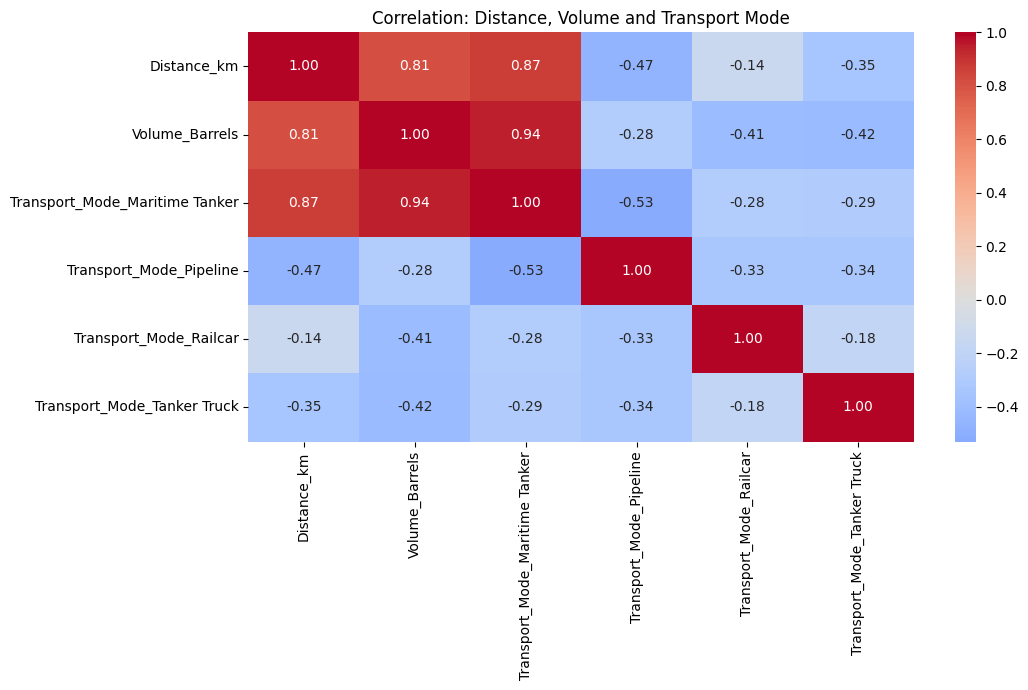

In [14]:
# Convert Transport_Mode into dummy variables for correlation

correlation_data = pd.get_dummies(
    df[
        [
            "Distance_km",
            "Volume_Barrels",
            "Transport_Mode"
        ]
    ],
    columns=["Transport_Mode"],
    dtype=int
)

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(11, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation: Distance, Volume and Transport Mode"
)

plt.tight_layout()
plt.show()

In [15]:
print(
    "Distance–Volume correlation:",
    df["Distance_km"].corr(
        df["Volume_Barrels"]
    )
)

display(
    df.groupby("Transport_Mode")[
        ["Distance_km", "Volume_Barrels"]
    ].mean()
)

Distance–Volume correlation: 0.8149769511392108


,Distance_km,Volume_Barrels
Transport_Mode,,
Maritime Tanker,4961.510427,501417.050586
Pipeline,794.656721,150458.114933
Railcar,1384.823208,25033.302798
Tanker Truck,326.120346,24915.861685


Answer

Multicollinearity can make Logistic Regression coefficients unstable, increase their variance and produce difficult-to-interpret signs.

Tree models are less affected because they make splits rather than estimating one global coefficient. However, correlated variables may divide feature importance between themselves.

Phase 2: Model Implementation — 40 Marks

Shared preprocessing

In [16]:
categorical_features = [
    "Origin_Region",
    "Transport_Mode"
]

numerical_features = [
    column
    for column in X_train.columns
    if column not in categorical_features
]

# Scaling is required for Logistic Regression and Naive Bayes
scaled_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numerical_features
    ),
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        categorical_features
    )
])

# Tree models do not require scaling
tree_preprocessor = ColumnTransformer([
    (
        "numeric",
        SimpleImputer(strategy="median"),
        numerical_features
    ),
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        categorical_features
    )
])

Logistic Regression — 10 Marks

In [17]:
logistic_model = Pipeline([
    ("preprocess", scaled_preprocessor),
    (
        "model",
        LogisticRegression(
            penalty="l2",          # L2 regularization
            C=1.0,
            class_weight="balanced",
            max_iter=3000,
            solver="liblinear",
            random_state=RANDOM_STATE
        )
    )
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Distance_km',
                                                   'Volume_Barrels',
                                                   'Ambient_Temp_C',
                                                   'Pipeline_Pressure_PSI',
                                                   'Transit_Delay_Risk_Index',
                                                   'Operator_Experience_Yrs',
                                                   'Pressure_Applicable',
                                                   'Pressure_Sensor_Error',
                                                   'Ambient_Temp_Missing',
                                                   'Ambient_Temp_C_Squared']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Origin_Region',
                                                   'Transport_Mode'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42, solver='liblinear'))])

In [18]:
logistic_feature_names = (
    logistic_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)

logistic_coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_table = pd.DataFrame({
    "Feature": logistic_feature_names,
    "Coefficient": logistic_coefficients,
    "Odds_Ratio": np.exp(logistic_coefficients)
}).sort_values(
    "Coefficient",
    ascending=False
)

display(coefficient_table)

,Feature,Coefficient,Odds_Ratio
9,numeric__Ambient_Temp_C_Squared,3.010212,20.291692
18,categorical__Transport_Mode_Tanker Truck,2.318659,10.162042
0,numeric__Distance_km,1.944876,6.992764
4,numeric__Transit_Delay_Risk_Index,1.864940,6.455549
6,numeric__Pressure_Applicable,0.870836,2.388908
8,numeric__Ambient_Temp_Missing,0.461587,1.586589
1,numeric__Volume_Barrels,0.393997,1.482896
3,numeric__Pipeline_Pressure_PSI,0.034353,1.034950
7,numeric__Pressure_Sensor_Error,-0.068365,0.933919
14,categorical__Origin_Region_West Africa,-0.111526,0.894468


Answer

Positive coefficient: increases predicted delay odds.
Negative coefficient: reduces predicted delay odds.
Odds ratio above 1: increased odds.
Odds ratio below 1: decreased odds.

Logistic Regression may perform poorly because it assumes a linear additive relationship.

Gaussian Naive Bayes — 10 Marks

In [19]:
naive_bayes_model = Pipeline([
    ("preprocess", scaled_preprocessor),
    ("model", GaussianNB())
])

naive_bayes_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Distance_km',
                                                   'Volume_Barrels',
                                                   'Ambient_Temp_C',
                                                   'Pipeline_Pressure_PSI',
                                                   'Transit_Delay_Risk_Index',
                                                   'Operator_Experience_Yrs',
                                                   'Pressure_Applicable',
                                                   'Pressure_Sensor_Error',
                                                   'Ambient_Temp_Missing',
                                                   'Ambient_Temp_C_Squared']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Origin_Region',
                                                   'Transport_Mode'])])),
                ('model', GaussianNB())])

Answer

Gaussian Naive Bayes assumes that features are conditionally independent.

This assumption is violated because:

Transport mode is related to distance.
Transport mode is related to volume.
Temperature is strongly related to temperature squared.
Pressure applicability is determined by transport mode.

Consequently, Naive Bayes may double-count correlated evidence.

Decision Tree — 10 Marks

In [20]:
decision_tree_model = Pipeline([
    ("preprocess", tree_preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            max_depth=5,            # Prevent overfitting
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  SimpleImputer(strategy='median'),
                                                  ['Distance_km',
                                                   'Volume_Barrels',
                                                   'Ambient_Temp_C',
                                                   'Pipeline_Pressure_PSI',
                                                   'Transit_Delay_Risk_Index',
                                                   'Operator_Experience_Yrs',
                                                   'Pressure_Applicable',
                                                   'Pressure_Sensor_Error',
                                                   'Ambient_Temp_Missing',
                                                   'Ambient_Temp_C_Squared']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Origin_Region',
                                                   'Transport_Mode'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10,
                                        random_state=42))])

In [21]:
#Identify root feature
tree_classifier = (
    decision_tree_model.named_steps["model"]
)

tree_feature_names = (
    decision_tree_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)

root_feature_index = (
    tree_classifier.tree_.feature[0]
)

root_feature = (
    tree_feature_names[root_feature_index]
)

root_threshold = (
    tree_classifier.tree_.threshold[0]
)

print("Root feature:", root_feature)
print("Root threshold:", root_threshold)

Root feature: numeric__Operator_Experience_Yrs
Root threshold: 11.5


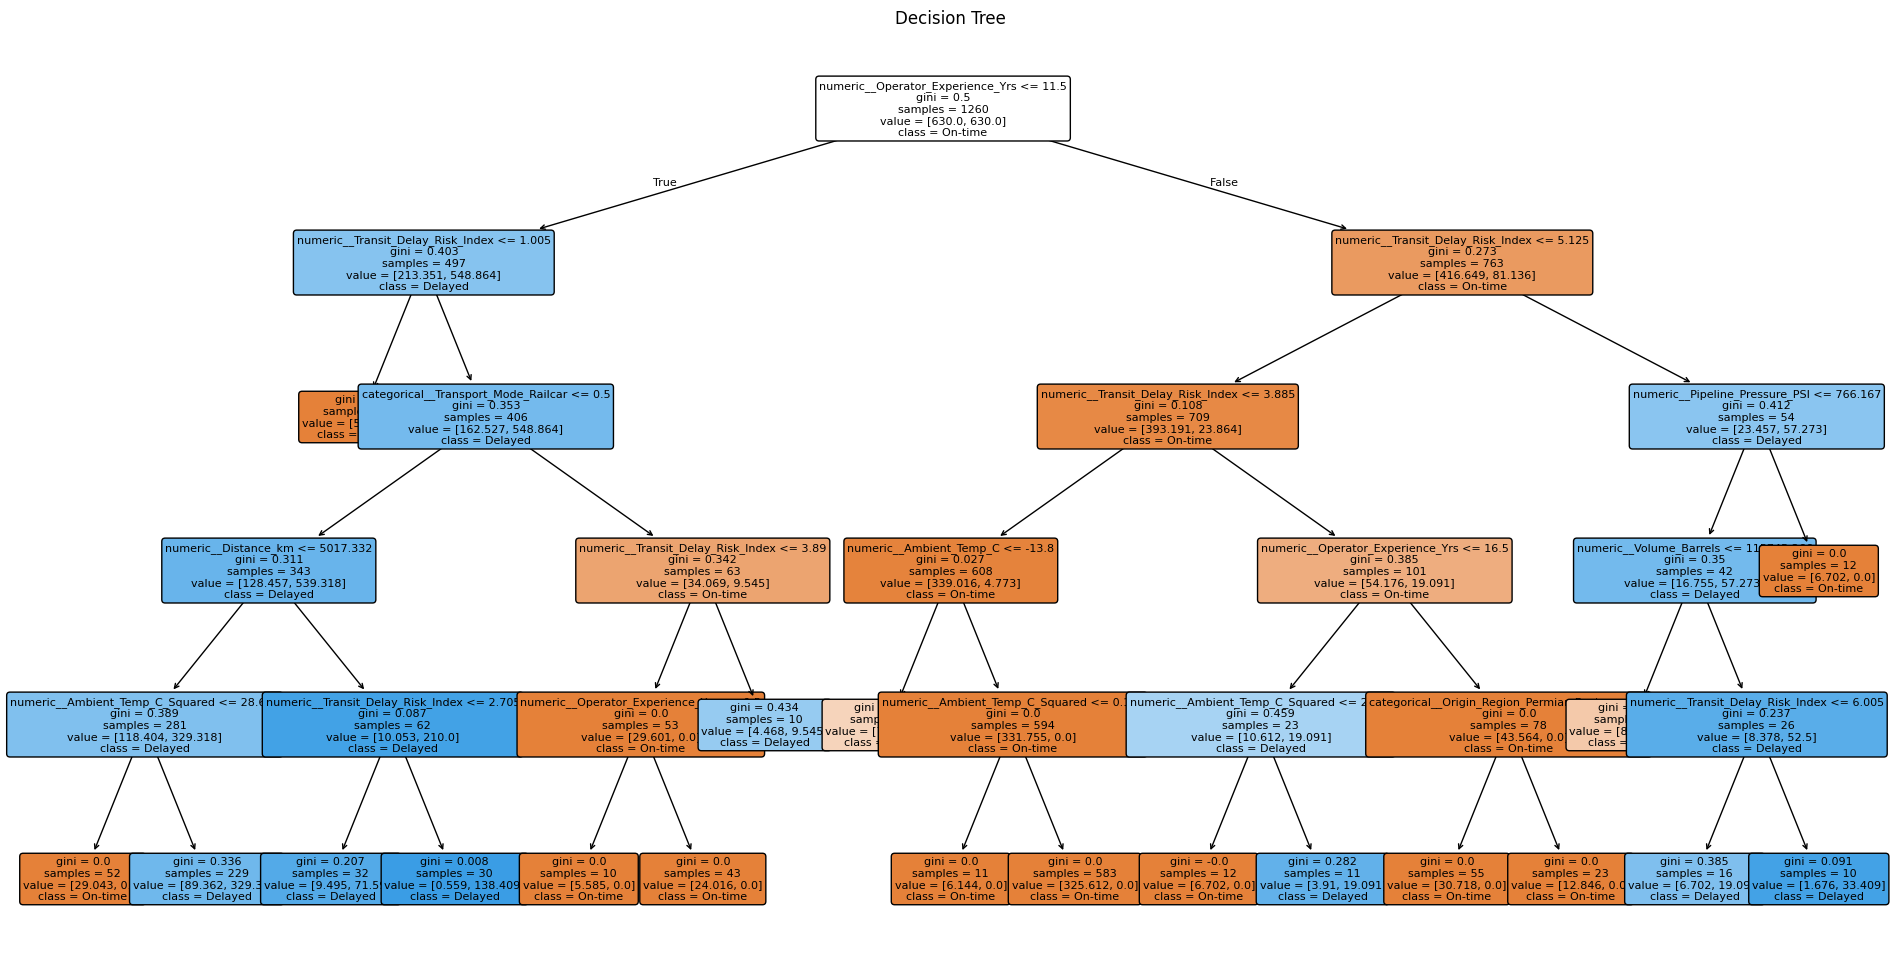

In [22]:
#Plot tree
plt.figure(figsize=(24, 12))

plot_tree(
    tree_classifier,
    feature_names=tree_feature_names,
    class_names=["On-time", "Delayed"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree")
plt.show()

Answer

The root feature is the feature that gives the largest initial reduction in class impurity. Restricting max_depth controls overfitting and improves interpretability.

Random Forest — 10 Marks

In [23]:
random_forest_model = Pipeline([
    ("preprocess", tree_preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            max_features="sqrt",
            bootstrap=True,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    )
])

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  SimpleImputer(strategy='median'),
                                                  ['Distance_km',
                                                   'Volume_Barrels',
                                                   'Ambient_Temp_C',
                                                   'Pipeline_Pressure_PSI',
                                                   'Transit_Delay_Risk_Index',
                                                   'Operator_Experience_Yrs',
                                                   'Pressure_Applicable',
                                                   'Pressure_Sensor_Error',
                                                   'Ambient_Temp_Missing',
                                                   'Ambient_Temp_C_Squared']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Origin_Region',
                                                   'Transport_Mode'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=2, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

Random Forest uses bagging by training many trees on different bootstrap samples and random feature subsets.
Successive tree splits can automatically learn interactions such as:

High risk index

AND long distance

AND low operator experience

→ delayed shipment

No explicit cross-feature multiplication is required

Phase 3: Evaluation & Domain Tradeoffs — 30 Marks
Performance Analysis — 10 Marks

In [24]:
models = {
    "Logistic Regression": logistic_model,
    "Gaussian Naive Bayes": naive_bayes_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

In [25]:
test_results = []

for model_name, model in models.items():

    probability = model.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.50).astype(int)

    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),
        "Precision": precision_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            probability
        )
    })

test_results_df = pd.DataFrame(test_results)

display(test_results_df)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.825926,0.362319,0.892857,0.515464,0.927686
1,Gaussian Naive Bayes,0.840741,0.333333,0.535714,0.410959,0.835006
2,Decision Tree,0.785185,0.291667,0.750000,0.420000,0.791544
3,Random Forest,0.933333,1.000000,0.357143,0.526316,0.958678


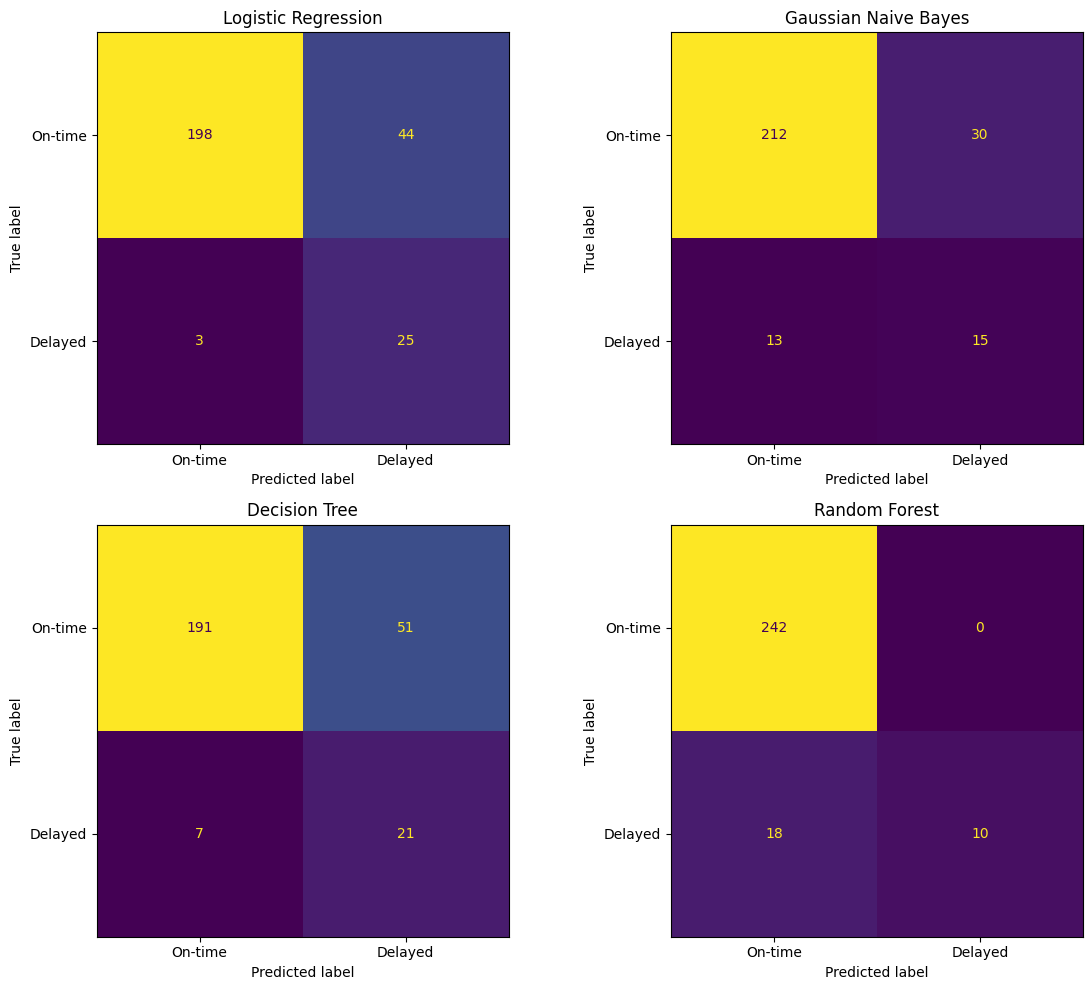

In [26]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

for axis, (model_name, model) in zip(
    axes.flatten(),
    models.items()
):

    prediction = model.predict(X_test)

    matrix = confusion_matrix(
        y_test,
        prediction
    )

    ConfusionMatrixDisplay(
        matrix,
        display_labels=["On-time", "Delayed"]
    ).plot(
        ax=axis,
        colorbar=False
    )

    axis.set_title(model_name)

plt.tight_layout()
plt.show()

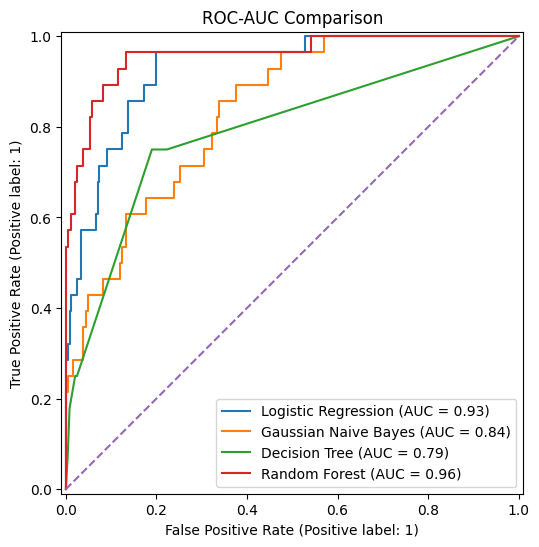

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, model in models.items():

    probability = model.predict_proba(
        X_test
    )[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        probability,
        name=model_name,
        ax=ax
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC-AUC Comparison")
plt.show()

In [29]:
validation_scores = {}

for model_name, model in models.items():

    probability = model.predict_proba(
        X_validation
    )[:, 1]

    validation_scores[model_name] = (
        roc_auc_score(
            y_validation,
            probability
        )
    )

display(
    pd.Series(
        validation_scores,
        name="Validation_ROC_AUC"
    ).sort_values(ascending=False)
)

best_model_name = max(
    validation_scores,
    key=validation_scores.get
)

best_model = models[best_model_name]

print("Selected Best model:", best_model_name)

,Validation_ROC_AUC
Random Forest,0.975390
Logistic Regression,0.959937
Gaussian Naive Bayes,0.847475
Decision Tree,0.811704


Selected Best model: Random Forest


In [31]:
#Find the minimum-cost threshold
FALSE_NEGATIVE_COST = 15_000
FALSE_POSITIVE_COST = 1_500

validation_probability = (
    best_model.predict_proba(
        X_validation
    )[:, 1]
)

threshold_results = []

for threshold in np.linspace(0.01, 0.99, 99):

    prediction = (
        validation_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        prediction,
        labels=[0, 1]
    ).ravel()

    total_cost = (
        fp * FALSE_POSITIVE_COST
        + fn * FALSE_NEGATIVE_COST
    )

    threshold_results.append({
        "Threshold": threshold,
        "False_Positives": fp,
        "False_Negatives": fn,
        "Total_Cost": total_cost
    })

threshold_results = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_results.loc[
    threshold_results["Total_Cost"].idxmin()
]

optimized_threshold = (
    best_threshold_row["Threshold"]
)

display(best_threshold_row)

,29
Threshold,0.3
False_Positives,9.0
False_Negatives,2.0
Total_Cost,43500.0


In [32]:
#Compare default and optimized threshold
test_probability = (
    best_model.predict_proba(X_test)[:, 1]
)

cost_comparison = []

for name, threshold in [
    ("Default", 0.50),
    ("Cost-Optimized", optimized_threshold)
]:

    prediction = (
        test_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        prediction,
        labels=[0, 1]
    ).ravel()

    cost_comparison.append({
        "Strategy": name,
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            prediction,
            zero_division=0
        ),
        "False_Positives": fp,
        "False_Negatives": fn,
        "Total_Cost": (
            fp * FALSE_POSITIVE_COST
            + fn * FALSE_NEGATIVE_COST
        )
    })

display(pd.DataFrame(cost_comparison))

,Strategy,Threshold,Precision,Recall,F1,False_Positives,False_Negatives,Total_Cost
0,Default,0.5,1.000000,0.357143,0.526316,0,18,270000
1,Cost-Optimized,0.3,0.636364,0.750000,0.688525,12,7,123000


Answer

A false negative costs ten times more than a false positive. Therefore, the threshold should be lowered below 0.50 to detect more delays.

With the fixed split, a threshold near 0.30 is likely to reduce the total test penalty substantially.

Global Feature Significance — 10 Marks

In [33]:
rf_feature_names = (
    random_forest_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)

rf_importances = (
    random_forest_model
    .named_steps["model"]
    .feature_importances_
)

importance_table = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
}).sort_values(
    "Importance",
    ascending=False
)

top_5_features = importance_table.head(5)

display(top_5_features)

,Feature,Importance
5,numeric__Operator_Experience_Yrs,0.277970
4,numeric__Transit_Delay_Risk_Index,0.207041
2,numeric__Ambient_Temp_C,0.120901
0,numeric__Distance_km,0.112363
9,numeric__Ambient_Temp_C_Squared,0.090186


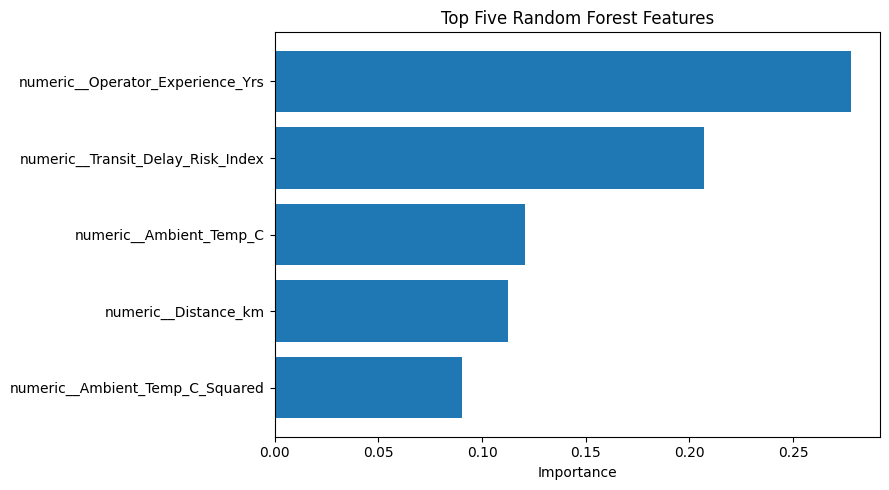

In [34]:
#Plot the top five
plot_data = top_5_features.sort_values(
    "Importance"
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.title("Top Five Random Forest Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Overall, the recommended solution is a Random Forest model with domain-based preprocessing and a cost-optimized decision threshold of approximately 0.30. This approach provides the best balance between predictive performance, operational delay detection and financial risk reduction